## Import Libraries and Initial Configuration

In [ ]:
!pip -q install datasets nltk hnswlib sentencepiece wordninja

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.6/541.6 kB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from google.colab import drive
import os

from datasets import load_dataset

import numpy as np

import torch

import pandas as pd
import matplotlib.pyplot as plt

import re

from collections import Counter

import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk import pos_tag

from scipy.stats import pearsonr

from mpl_toolkits.mplot3d import Axes3D

import seaborn as sns

import random

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import plotly.graph_objects as go
import plotly.express as px

import wordninja

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

os.chdir(f'/content/drive/MyDrive/project_nlp')
os.getcwd()

'/content/drive/MyDrive/project_nlp'

# Data Preparation

## Dataset Import

In [ ]:
# Load the RACE dataset, specifying the desired configuration

dataset_complete = load_dataset("ehovy/race", "all")
dataset_high = load_dataset("ehovy/race", "high")
dataset_middle = load_dataset("ehovy/race", "middle")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/11.0k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/2.08M [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/37.4M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/2.05M [00:00<?, ?B/s]

...

train-00000-of-00001.parquet:   0%|          | 0.00/6.97M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/407k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/1436 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/25421 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1436 [00:00<?, ? examples/s]

## Dataset Manipulation

**Observation**: The original dataset contained many duplicated articles, with each question linked to its corresponding article in the table. To improve efficiency, we decided to compress the dataset by keeping each article only once and nesting all related questions within it.

This version is more direct and easier to understand while preserving the original meaning.

First i will recostruct the data using multiple dictionaries containing each an id of the article as key and inside it the text of the article with in it also the text of the article and the list of questions and answers.

In [ ]:
def create_article_mapping(dataset_complete):
    """Create a consistent article to ID mapping for the complete dataset"""
    article_to_id = {}
    for split in ['train', 'validation', 'test']:
      for example in dataset_complete[split]:
          article = example['article']
          if article not in article_to_id:
              article_to_id[article] = len(article_to_id)
    return article_to_id

In [ ]:
def restructure_dataset_with_mapping(dataset, article_to_id):
    """
    Restructures dataset using pre-defined article IDs
    Returns dictionary with article_id as keys
    """
    restructured = {}

    for example in dataset:
        article = example['article']
        article_id = article_to_id[article]

        question_info = {
            'example_id': example['example_id'],
            'question': example['question'],
            'options': example['options'],
            'answer': example['answer']
        }

        if article_id not in restructured:
            restructured[article_id] = {
                'article_text': article,
                'questions': []
            }

        restructured[article_id]['questions'].append(question_info)

    return restructured

In [ ]:
# First create the unified mapping using the complete dataset
article_to_id = create_article_mapping(dataset_complete)

# Then restructure all datasets using the same mapping
middle_train_dict = restructure_dataset_with_mapping(dataset_middle['train'], article_to_id)
high_train_dict = restructure_dataset_with_mapping(dataset_high['train'], article_to_id)
complete_train_dic = restructure_dataset_with_mapping(dataset_complete['train'], article_to_id)

middle_validation_dict = restructure_dataset_with_mapping(dataset_middle['validation'], article_to_id)
high_validation_dict = restructure_dataset_with_mapping(dataset_high['validation'], article_to_id)
complete_validation_dict = restructure_dataset_with_mapping(dataset_complete['validation'], article_to_id)


middle_test_dict = restructure_dataset_with_mapping(dataset_middle['test'], article_to_id)
high_test_dict = restructure_dataset_with_mapping(dataset_high['test'], article_to_id)
complete_test_dict = restructure_dataset_with_mapping(dataset_complete['test'], article_to_id)

In [ ]:
dataset_dict = {  # Initialize as a dictionary
    'middle': {
        'train': middle_train_dict,
        'validation': middle_validation_dict,
        'test': middle_test_dict
    },
    'high': {
        'train': high_train_dict,
        'validation': high_validation_dict,
        'test': high_test_dict
    },
    'all': {
        'train': complete_train_dic,
        'validation': complete_validation_dict,
        'test': complete_test_dict
    }
}

In [ ]:
print(len(dataset_dict['middle']['test']))

362


In [ ]:
dataset_dict['all']['train'][998]

{'article_text': 'LONDON, Aug. 19 (Xinhua) -- A four-year-old child\'s ability to draw could be an indicator of intelligence at age 14, according to a study published on Tuesday in the British journal Psychological Science.\nThe researchers from King\'s College London (KCL) studied 7,752 pairs of identical and non-identical twins, and found that the link between drawing and later intelligence was influenced by genes.\nAt the age of 4, children were asked by their parents to complete a \'Draw-a-Child\' test. Their drawings were rated from 0 to 12, based on the presence and correct number of body-parts, like arms, legs, head, eyes and nose.\nThe children were also given verbal and non-verbal intelligence tests at ages 4 and 14. According to researchers, the test was devised in the 1920\'s to assess children\'s intelligence, so it\'s not surprising that the test correlated with intelligence at age 4.However, they found that higher scores on the test were also moderately associated with hi

## Splitninja

Quick note: this dataset is bad. It has several bad formatting. The first time I tried to produce this 3d plot I immediately realized there were some incogruencies.

Article 21118 has no spaces between words

In [ ]:
middle_train_dict[21118]

{'article_text': 'Somepeoplethinkthatsingingcanliftourspirits ,whilesomeotherpeople  don\'tthinkso.Theydon\'tlikesingingandtheythinksingingcannevermakethemhappy.Ido thinksingingcanmakeusfeelgood,anditcanliftourspirits.Letmetellyoumoreaboutthat.\nSomeresearchers oncedidsomesurveysandprovedit.Thesurveysshow  thatsingingcanbringalotofhealthbenefits .Ifyousingwithyourfriends,theeffectsmay be evenbetter.\nJohnLennonwasonceateacherofVocalPerformance atEmporiaState University.Hesays,"Singingisaninborn need.Babiessingtothemselvesandthey seemsohappy.Likebabies,whenwesing,wefeelsogoodandsingingmakesusfeelevenbetter.I likesingingandIamhappyeveryday."\nMusicisapartofhumannature.Andsingingisaformof _ thatcanbeunderstoodby everyone.Somepeoplesaythatmusicislikeakindoflanguage.Thelanguagecanshow people\'sopinionsandattitudes totheirlife.Somesongscancheerpeopleupwhentheyarein trouble.Somesongscanmakepeoplehappyandexcited.That\'swhytheTVshowTheVoiceof Chinaissopopularwithpeople.',
 'questions': [{'examp

In [ ]:
high_train_dict[11910]

{'article_text': 'TheUnitedStateshasaround475,000schoolbuses.Eachdaytheycarrymorethan25million children,halfofalltheschoolchildreninthecountry.\nThesebuses,onaverage,use4litersofdiesel fueltotravellessthan16kilometers. When theschoolyearbeganlastfall,dieselaveraged55centsaliternationally.Thepricenearlydoubledby theendofschool inJune.\nBobRileyisthespokesmanfortheAmericanSchoolBusCouncil.Hesaysfuelpricesnegotiated  for schools arenot lower thanothers have to pay. Asaresult,schoolsarelookingfor waystoreducetransportationcosts.Busroutesarebeing redrawnor,insomecases,canceled.Someareas arebuyingbusesthatuse naturalgas orother alternativefuels.\nOtherstepsincludefewerfieldtrips andlesstravel bysports teams.Someschool districtsmayend any busservicenotrequiredby law.\nStudiesshowthatschoolbusesarethesafestform oftransportationtoandfrom school.\nThe AmericanSchoolBus Councilsayscutsinbus serviceare badfor childrenandpossiblythe environment.Itsaysremovingbusesfromtheroadwillmeananincreaseinothe

proof that it was not our fault:
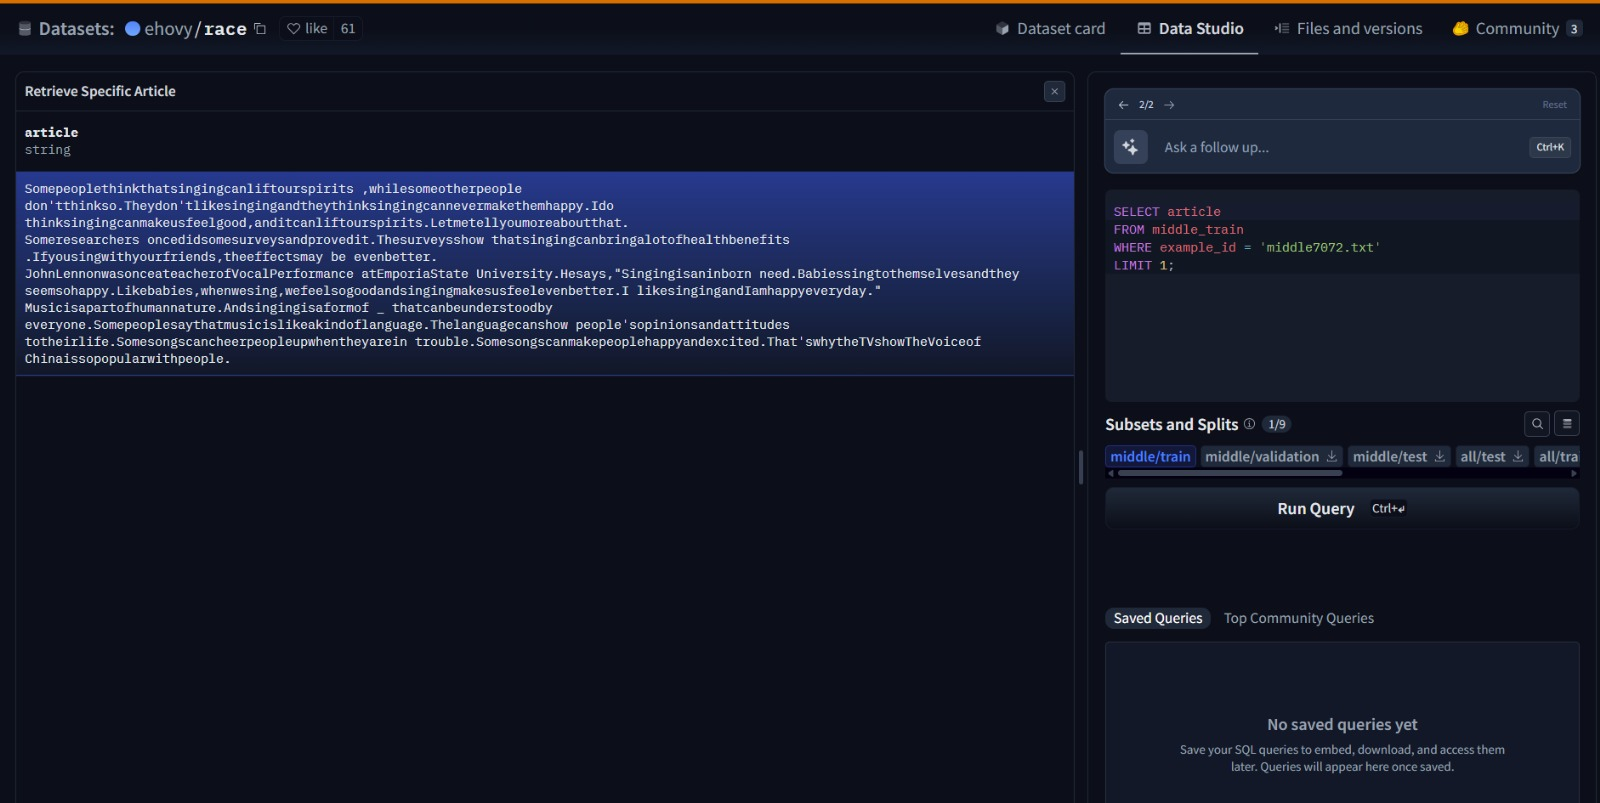

**Approach to Handling Merged Words**
To address this issue, we used the SplitNinja library, but only in cases where we detected unusually long words (those exceeding 15 characters). We avoided applying SplitNinja to the entire dataset for two key reasons:



1.   **Computational Efficiency:** Processing every document would have been unnecessarily resource-intensive.
2.   **Risk of Over-Splitting:** Since most articles were already correctly split, running SplitNinja universally could have introduced errors. The library works by first merging all words and then re-splitting them statistically, which might disrupt properly formatted text.


**Conclusion**
We opted for a conservative approach, applying SplitNinja only when we had strong evidence of merged words (e.g., extreme word length). While this strategy may have missed some edge cases or left minor errors uncorrected, it prioritized precision over coverage—a tradeoff we deemed necessary to maintain data integrity.



There is one last problem we had to face. Splitninja removed punctuation so we need a wrapper function to keep it:

In [ ]:
def smart_split(text, min_word_length=15):
    # 1) Normalize line breaks
    text = text.replace('.\n', ' . ')
    text = text.replace('\n', ' . ')

    # 2) Ensure long words ending with punctuation get separated from the next capitalized word
    #    (using only . ? ! for example; extend the class as you like)
    text = re.sub(r'(\b\w{3,})([.!?])\s*(\b[A-Z]\w{2,})',
                  r'\1 \2 \3',
                  text)

    # 3) Tokenize into “words” vs everything else
    tokens = re.findall(r'([A-Za-z]+|[^A-Za-z])', text)

    # 4) Rebuild with spaces after every token
    processed = []
    for token in tokens:
        if token.isalpha():
            # split long “words” into subwords
            processed.extend(wordninja.split(token))
        else:
            if(token!= ' '):
              processed.append(token)

    text = " ".join(processed)

    # 5) Clean up spaces before punctuation (e.g. remove the space before . ? ! , etc.)
    text = re.sub(r'(\w)\s+([.?!,;:—…])', r'\1\2', text)

    return text

Test to see if the word tokenizer works as expected:

In [ ]:
# Test
text = "Hello.World\nThisIsATest. Hello"
processed = smart_split(text)
processed

'Hello. World. This Is A Test. Hello'

unfortunately it has some problem when it comes to apostrophes but covering all case would cost me too much time.

In [ ]:
# Test
text = "I'm the best programmer cause I'\m the best"
processed = smart_split(text)
processed

"I ' m the best programmer cause I ' \\ m the best"

In [ ]:
def apply_wordninja_splitting(restructured_data, char_threshold=20):
    """
    Applies wordninja splitting ONLY to documents containing at least one
    word with more than `char_threshold` characters.
    """
    subsets = ['high', 'middle', 'all']
    splits = ['train', 'validation', 'test']

    for subset in subsets:
        for split in splits:
            data_for_subset = restructured_data[subset][split]
            for article_id in data_for_subset:
                original_text = data_for_subset[article_id]['article_text']

                # Check if document contains any long words
                has_long_word = any(
                    len(word) > char_threshold
                    for word in original_text.split()  # Simple space-based tokenization
                )

                # Apply wordninja only if long words detected
                if has_long_word:
                    #print(subset + ' ' + split + ' ' + str(article_id))
                    processed_text = smart_split(original_text)
                    data_for_subset[article_id]['article_text'] = processed_text

    return restructured_data

dataset_dict=apply_wordninja_splitting(dataset_dict)

Now if we check though for the previously critical datasets that had a lot of words unified it seems that they are not unified anymore

In [ ]:
middle_train_dict[21118]

{'article_text': 'Some people think that singing can lift our spirits, while some other people don \' t think so. They don \' t like singing and they think singing can never make them happy. Ido think singing can make us feelgood, and it can lift our spirits. Let me tell you more about that. Some researchers once did some surveys and proved it. The surveys show that singing can bring a lot of health benefits. If you sing with your friends, the effects may be even better. John Lennon was once a teacher of Vocal Performance at Emporia State University. He says, " Singing is an in born need. Babies sing to themselves and they seem so happy. Like babies, when we sing, we feel so good and singing makes us feel even better. I like singing and Iam happy everyday. " . Music is apart of human nature. And singing is a form of _ that can be understood by everyone. Some people say that music is like a kind of language. The language can show people \' s opinions and attitudes to their life. Some so

In [ ]:
high_train_dict[11910]

{'article_text': 'The United States has around 4 7 5, 0 0 0 school buses. Each day they carry more than 2 5 million children, half of all the schoolchildren in the country. These buses, on average, use 4 liters of diesel fuel to travel less than 1 6 kilometers. When the school year began last fall, diesel averaged 5 5 cents a liter nationally. The price nearly doubled by the end of school in June. Bob Riley is the spokesman for the American School Bus Council. He says fuel prices negotiated for schools are not lower than others have to pay. As a result, schools are looking for ways to reduce transportation costs. Bus routes are being redrawn or, in some cases, canceled. Some areas are buying buses that use natural gas or other alternative fuels. Other steps include fewer field trips and less travel by sports teams. Some school districts may end any bus service not required by law. Studies show that school buses are the safest form of transportation to and from school. The American Scho

This has a price though: normally long words like websites were divided. Moreover word Ninja computes decently fast but sometimes makes some small error so this is something to be noted.

# INFO TO MERGE THE NOTEBOOKS




> Q&A WITH BERT CONTAINS ALL MY CODE





# Q&A WITH BERT


## SETUP

**Import Libraries**

In [ ]:
from datasets import Dataset, DatasetDict
from transformers import BertForMultipleChoice, BertTokenizerFast, DebertaV2ForMultipleChoice, DebertaV2TokenizerFast, Trainer, TrainingArguments
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import torch.nn.functional as F

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
import logging
logging.getLogger("transformers.tokenization_utils_base").setLevel(logging.ERROR)

**Preprocess data and create Dataset**

Since the data are organized in a way that for each text there are multiple questions with multiple answers we split them

The obtained datastructure is a list of dictionaries with these keys:



1.   article_text = contains the article
2.   question = containse one single question
3.   options = contains the 4 multiple choice answers
4.   difficulty = contains middle or high (used to analyze the performances)
5.   label = contains a number between 0 and 3 that indicates the right option



In [ ]:
#function that split the dataset elements to obtain the structure described above
def split_questions(dataset):

  new_dataset = []
  mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3}

  for entry in dataset.items():
    context = entry[1]["article_text"]
    for q in entry[1]["questions"]:
      question = q["question"]
      options = q["options"]
      label = mapping[q["answer"]]
      if 'middle' in q['example_id']:
        difficulty = 'middle'
      else:
        difficulty = 'high'
      new_dataset.append({'article_text' : context, 'difficulty' : difficulty, 'question' : question, 'options' : options, 'label' : label})
  return new_dataset

In [ ]:
# Function to obtain a dataset of dictionaries for train, validation and test
def get_dataset_dict(data_type):
  train_dataset = split_questions(dataset_dict[data_type]['train'])
  validation_dataset = split_questions(dataset_dict[data_type]['validation'])
  test_dataset = split_questions(dataset_dict[data_type]['test'])
  data = DatasetDict()
  data['train'] = Dataset.from_list(train_dataset)
  data['validation'] = Dataset.from_list(validation_dataset)
  data['test'] = Dataset.from_list(test_dataset)
  return data

In [ ]:
# Creation of 3 dataset of dictionaries, one with all data, one with only middle and one with only high
data = get_dataset_dict('all')
middle_data = get_dataset_dict('middle')
high_data = get_dataset_dict('high')



---



Here we just print the splitted data compared to the original ones

In [ ]:
print(f"The len of the original train dataset with all data is {len(dataset_dict['all']['train'])}")
print(f"The len of the new train dataset with all data is {data['train'].__len__()}")
print(f"The len of the original validation dataset with all data is {len(dataset_dict['all']['validation'])}")
print(f"The len of the new validation dataset with all data is {data['validation'].__len__()}")
print(f"The len of the original test dataset with all data is {len(dataset_dict['all']['test'])}")
print(f"The len of the new test dataset with all data is {data['test'].__len__()}")

The len of the original train dataset with all data is 25135
The len of the new train dataset with all data is 87866
The len of the original validation dataset with all data is 1389
The len of the new validation dataset with all data is 4887
The len of the original test dataset with all data is 1407
The len of the new test dataset with all data is 4934


In [ ]:
print(f"The len of the original train dataset with middle data is {len(dataset_dict['middle']['train'])}")
print(f"The len of the new train dataset with middle data is {middle_data['train'].__len__()}")
print(f"The len of the original validation dataset with middle data is {len(dataset_dict['middle']['validation'])}")
print(f"The len of the new validation dataset with middle data is {middle_data['validation'].__len__()}")
print(f"The len of the original test dataset with middle data is {len(dataset_dict['middle']['test'])}")
print(f"The len of the new test dataset with middle data is {middle_data['test'].__len__()}")

The len of the original train dataset with middle data is 6409
The len of the new train dataset with middle data is 25421
The len of the original validation dataset with middle data is 368
The len of the new validation dataset with middle data is 1436
The len of the original test dataset with middle data is 362
The len of the new test dataset with middle data is 1436


In [ ]:
print(f"The len of the original train dataset with high data is {len(dataset_dict['high']['train'])}")
print(f"The len of the new train dataset with high data is {high_data['train'].__len__()}")
print(f"The len of the original validation dataset with high data is {len(dataset_dict['high']['validation'])}")
print(f"The len of the new validation dataset with high data is {high_data['validation'].__len__()}")
print(f"The len of the original test dataset with high data is {len(dataset_dict['high']['test'])}")
print(f"The len of the new test dataset with high data is {high_data['test'].__len__()}")

The len of the original train dataset with high data is 18726
The len of the new train dataset with high data is 62445
The len of the original validation dataset with high data is 1021
The len of the new validation dataset with high data is 3451
The len of the original test dataset with high data is 1045
The len of the new test dataset with high data is 3498




---



In [ ]:
# Print the example of one training data
data['train'].__getitem__(0)

{'article_text': 'Last week I talked with some of my students about what they wanted to do after they graduated, and what kind of job prospects  they thought they had.\nGiven that I teach students who are training to be doctors, I was surprised do find that most thought that they would not be able to get the jobs they wanted without "outside help". "What kind of help is that?" I asked, expecting them to tell me that they would need a   or family friend to help them out.\n"Surgery ," one replied.\nI was pretty alarmed by that response. It seems that the graduates of today are increasingly willing to go under the knife to get ahead of others when it comes to getting a job .\nOne girl told me that she was considering surgery to increase her height. "They break your legs, put in special extending screws, and slowly expand the gap between the two ends of the bone as it re-grows, you can get at least 5 cm taller!"\nAt that point, I was shocked. I am short, I can\'t deny that, but I don\'t th

In [ ]:
# initialize device to use cuda
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## TOKENIZATION

**This** is the tokenization part, since we are going to use multiple choice models we had to tokenize data in a particular way.
The model expects a list of 4 tokenized elements and a single label for each question, each of these elements is structured in this way:

>  `text, question + " " + option`

So in the end this is how a single data input looks:

> `list( tokenized(text, question option[0]), tokenized(text, question option[1]),      tokenized(text, question option[2]), tokenized(text, question option[3]) )`




> **label** = index of the right option

The model will compute a score for each of the 4 options independently, the higher one is the predicted answer








---



**Tokenization usefull functions**

In [ ]:
# Function called with map on dataset to tokenize data
def tokenize_function(examples, MAX_LENGTH=512):
  inputs_ids = []
  attention_mask = []
  token_type_ids = []
  labels = []
  for idx, context in enumerate(examples['article_text']):
    inputs = [
    tokenizer(
        context,
        examples['question'][idx] + " " + option,
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length"  # Needed for batching
      )
      for option in examples['options'][idx]
    ]

    inputs_ids.append([input['input_ids'] for input in inputs])
    attention_mask.append([input['attention_mask'] for input in inputs])
    token_type_ids.append([input['token_type_ids'] for input in inputs])
    labels.append(examples['label'][idx])

  return {
      "input_ids" : inputs_ids,
      "attention_mask" : attention_mask,
      "token_type_ids" : token_type_ids,
      "label" : labels
  }


### TOKENIZATION FOR BERT

Tokenization using the berts's model tokenizer, tokenization is applied to all the 3 dictionaries of dataset

In [ ]:
# Name of the used model
bert_model_name = "bert-base-uncased"

In [ ]:
# Initialization of the tokenizer
tokenizer = BertTokenizerFast.from_pretrained(bert_model_name)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
# Len of the vocabulary of the tokenizer
len(tokenizer.vocab)

30522

In [ ]:
# Tokenize data composed of both middle and high difficulty
tokenized_data = data.map(tokenize_function, batched=True, batch_size=32, remove_columns=data['train'].column_names)

Map:   0%|          | 0/87866 [00:00<?, ? examples/s]

Map:   0%|          | 0/4887 [00:00<?, ? examples/s]

Map:   0%|          | 0/4934 [00:00<?, ? examples/s]

In [ ]:
# Tokenize middle difficulty data
tokenized_middle_data = middle_data.map(tokenize_function, batched=True, batch_size=32, remove_columns=middle_data['train'].column_names)

Map:   0%|          | 0/25421 [00:00<?, ? examples/s]

Map:   0%|          | 0/1436 [00:00<?, ? examples/s]

Map:   0%|          | 0/1436 [00:00<?, ? examples/s]

In [ ]:
# Tokenize high difficulty data
tokenized_high_data = high_data.map(tokenize_function, batched=True, batch_size=32, remove_columns=high_data['train'].column_names)

Map:   0%|          | 0/62445 [00:00<?, ? examples/s]

Map:   0%|          | 0/3451 [00:00<?, ? examples/s]

Map:   0%|          | 0/3498 [00:00<?, ? examples/s]

In [ ]:
# Print the keys of one tokenized data
print(tokenized_data['train'][0].keys())

dict_keys(['label', 'input_ids', 'attention_mask', 'token_type_ids'])


### TOKENIZE FOR DEBERTA

Tokenization using the berts's model tokenizer, tokenization is applied to all the 3 dictionaries of dataset

In [ ]:
# Name of the used model
deberta_model_name = "microsoft/deberta-v3-base"

In [ ]:
# Initialization of the tokenizer
tokenizer = DebertaV2TokenizerFast.from_pretrained(deberta_model_name)

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:559: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [ ]:
# Len of the vocabulary of the tokenizer
len(tokenizer.vocab)

128001

In [ ]:
# Tokenize data composed of both middle and high difficulty
tokenized_data = data.map(tokenize_function, batched=True, batch_size=32, remove_columns=data['train'].column_names)

Map:   0%|          | 0/87866 [00:00<?, ? examples/s]

Map:   0%|          | 0/4887 [00:00<?, ? examples/s]

Map:   0%|          | 0/4934 [00:00<?, ? examples/s]

In [ ]:
# Tokenize middle difficulty data
tokenized_middle_data = middle_data.map(tokenize_function, batched=True, batch_size=32, remove_columns=middle_data['train'].column_names)

Map:   0%|          | 0/25421 [00:00<?, ? examples/s]

Map:   0%|          | 0/1436 [00:00<?, ? examples/s]

Map:   0%|          | 0/1436 [00:00<?, ? examples/s]

In [ ]:
# Tokenize high difficulty data
tokenized_high_data = high_data.map(tokenize_function, batched=True, batch_size=32, remove_columns=high_data['train'].column_names)

Map:   0%|          | 0/62445 [00:00<?, ? examples/s]

Map:   0%|          | 0/3451 [00:00<?, ? examples/s]

Map:   0%|          | 0/3498 [00:00<?, ? examples/s]

In [ ]:
# Print the keys of one tokenized data
print(tokenized_data['train'][0].keys())

dict_keys(['label', 'input_ids', 'attention_mask', 'token_type_ids'])


## BERT MODEL TRAINING

In this section, we train the bert-base-uncased model three times: once using training data containing both Middle and High difficulty examples, once using only Middle difficulty training data, and once using only High difficulty training data.

This setup allows us to analyze the differences in performance between a model trained on diverse data versus models trained on specialized subsets.
We expect the model trained on all difficulties to achieve higher accuracy, as it will be exposed to a wider variety of texts and questions, while the specialized models will learn from a more restricted set of examples.


In [ ]:
# Prints the number of trainable parameters of the input model
def print_trainable_parameters(model):
    # Trainable parameters only
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {trainable_params}")

In [ ]:
# Loads the bert model and puts it inside device
def load_bert_model(model_name):
  bert_model = BertForMultipleChoice.from_pretrained(model_name)
  bert_model.to(device)
  return bert_model

In [ ]:
# Training arguments used for the training
bert_training_args = TrainingArguments(
    "BertUncasedTrainer",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    eval_strategy="no",
    num_train_epochs=3,
    weight_decay=0.01,
    fp16=True,
    report_to="none",  # Disabling wandb callbacks
)

### TRAIN BERT ON ALL TRAINING DATA

**This sections contains simply the code to train the model on data containing both difficulties**





In [ ]:
bert_model = load_bert_model(bert_model_name)

In [ ]:
print_trainable_parameters(bert_model)

In [ ]:
bert_all_trainer = Trainer(
    model=bert_model,
    args=bert_training_args,
    train_dataset=tokenized_data['train'],
    eval_dataset=tokenized_data['validation']
)


In [ ]:
bert_all_trainer.train()

Step,Training Loss
500,1.332000
1000,1.205600
1500,1.151700
2000,1.101000
2500,1.074300
3000,1.049300
3500,1.030000
4000,1.020300
4500,1.001000
5000,0.996900


TrainOutput(global_step=16476, training_loss=0.7901185237831733, metrics={'train_runtime': 4421.8861, 'train_samples_per_second': 59.612, 'train_steps_per_second': 3.726, 'total_flos': 2.7741970102122086e+17, 'train_loss': 0.7901185237831733, 'epoch': 3.0})

In [ ]:
bert_all_trainer.evaluate()

{'eval_loss': 1.0313167572021484,
 'eval_runtime': 36.721,
 'eval_samples_per_second': 133.084,
 'eval_steps_per_second': 16.639,
 'epoch': 3.0}

In [ ]:
bert_all_trainer.save_model("./bert_all")  # saves model

### TRAIN BERT ON MIDDLE DIFFICULTY TRAINING DATA

**In this section we train the model on Middle difficulty data**

In [ ]:
bert_model = load_bert_model(bert_model_name)

BertForMultipleChoice(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, ele

In [ ]:
print_trainable_parameters(bert_model)

Trainable parameters: 109483009


In [ ]:
bert_middle_trainer = Trainer(
    model=bert_model,
    args=bert_training_args,
    train_dataset=tokenized_middle_data['train'],
    eval_dataset=tokenized_middle_data['validation']
)

In [ ]:
bert_middle_trainer.train()

Step,Training Loss
500,1.266100
1000,1.085400
1500,1.004600
2000,0.819600
2500,0.783200
3000,0.771300
3500,0.632500
4000,0.559100
4500,0.573300


TrainOutput(global_step=4767, training_loss=0.8167954115390478, metrics={'train_runtime': 1302.7692, 'train_samples_per_second': 58.539, 'train_steps_per_second': 3.659, 'total_flos': 8.026183301459558e+16, 'train_loss': 0.8167954115390478, 'epoch': 3.0})

In [ ]:
bert_middle_trainer.evaluate()

{'eval_loss': 0.9387235641479492,
 'eval_runtime': 10.8407,
 'eval_samples_per_second': 132.464,
 'eval_steps_per_second': 16.604,
 'epoch': 3.0}

In [ ]:
bert_middle_trainer.save_model("./bert_middle")  # saves model

### TRAIN BERT ON HIGH DIFFICULTY TRAINING DATA

**In this section we train the model on High difficulty data**

In [ ]:
bert_model = load_bert_model(bert_model_name)

Some weights of BertForMultipleChoice were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
print_trainable_parameters(bert_model)

Trainable parameters: 109483009


In [ ]:
bert_high_trainer = Trainer(
    model=bert_model,
    args=bert_training_args,
    train_dataset=tokenized_high_data['train'],
    eval_dataset=tokenized_high_data['validation']
)

In [ ]:
bert_high_trainer.train()

Step,Training Loss
500,1.357600
1000,1.285600
1500,1.226300


Step,Training Loss
500,1.357600
1000,1.285600
1500,1.226300
2000,1.177600
2500,1.158700
3000,1.127500
3500,1.103600
4000,1.028800
4500,0.898700
5000,0.889800


TrainOutput(global_step=11709, training_loss=0.8974805632035854, metrics={'train_runtime': 3192.5715, 'train_samples_per_second': 58.678, 'train_steps_per_second': 3.668, 'total_flos': 1.9715786800662528e+17, 'train_loss': 0.8974805632035854, 'epoch': 3.0})

In [ ]:
bert_high_trainer.evaluate()

{'eval_loss': 1.1094413995742798,
 'eval_runtime': 25.6021,
 'eval_samples_per_second': 134.793,
 'eval_steps_per_second': 16.874,
 'epoch': 3.0}

In [ ]:
bert_high_trainer.save_model("./bert_high")  # saves model

## MODELS EVALUATION

**Usefull functions for evaluation**

In [ ]:
# Draw the confusion matrix using the true labels and the predicted ones
def draw_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

In [ ]:
# Prints the report of classification metrics using the true labels and the predicted ones
def print_classification_report(y_true, y_pred):
    report = classification_report(y_true, y_pred, zero_division=1)
    print(report)

In [ ]:
# Extracts the labels from the data
def get_labels(data):
  labels = []
  for entry in data:
    labels.append(entry['label'])
  return labels

In [ ]:
all_labels = get_labels(data['test'])
high_labels = get_labels(high_data['test'])
middle_labels = get_labels(middle_data['test'])



---



### EVALUATION OF BERT MODELS



In [ ]:
# Computes the predicted labels on the input data using tha input trainer
def get_predictions(trainer, data):
  logits = trainer.predict(data)
  y_pred = torch.argmax(torch.tensor(logits.predictions), dim=1).numpy()
  return y_pred

**Results of the bert model without any fine tuning**

In [ ]:
base_bert_model = BertForMultipleChoice.from_pretrained(bert_model_name)

In [ ]:
bert_base_trainer = Trainer(
    model=base_bert_model,
    args=bert_training_args,
    train_dataset=tokenized_data['train'],
    eval_dataset=tokenized_data['validation']
)

Some weights of BertForMultipleChoice were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.




---



**Confusion matrix and performances on all test data before fine tuning**

We have checked the performances of the model before fine tuning on all the training data to have a baseline



---



In [ ]:
y_pred = get_predictions(bert_base_trainer, tokenized_data['test'])

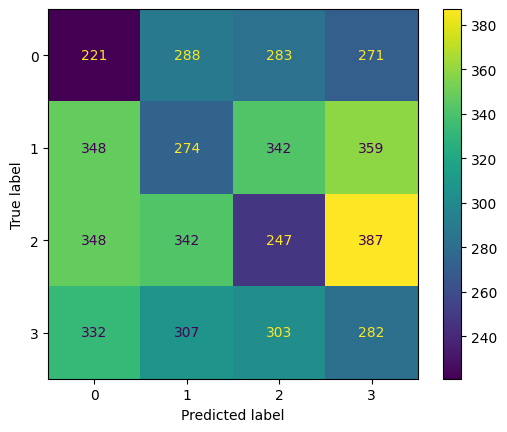

In [ ]:
draw_confusion_matrix(all_labels, y_pred)

In [ ]:
print_classification_report(all_labels, y_pred)

              precision    recall  f1-score   support

           0       0.18      0.21      0.19      1063
           1       0.23      0.21      0.22      1323
           2       0.21      0.19      0.20      1324
           3       0.22      0.23      0.22      1224

    accuracy                           0.21      4934
   macro avg       0.21      0.21      0.21      4934
weighted avg       0.21      0.21      0.21      4934





---



### PERFORMANCES OF BERT TRAINED ON ALL TRAINING DATA

**Results of the bert model fine tuned on all training data**

Now we extract some metrics of the model using test data and we compare performances on:



*   test data containing both difficulties
*   test data containing only middle difficulty
*   test data containing only high difficulty

We expect the second case to have the higher performances while the third one to have the lower.




---



In [ ]:
bert_all_model = load_bert_model("./bert_all")

BertForMultipleChoice(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, ele

In [ ]:
bert_all_trainer = Trainer(
    model=bert_all_model,
    args=bert_training_args,
)

**Confusion matrix and performances on all test data**

In [ ]:
y_pred = get_predictions(bert_all_trainer, tokenized_data['test'])

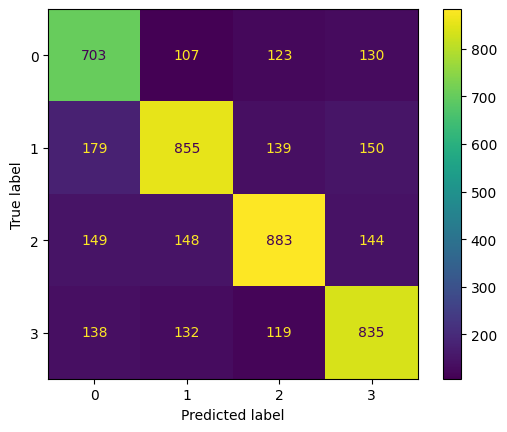

In [ ]:
draw_confusion_matrix(all_labels, y_pred)

In [ ]:
print_classification_report(all_labels, y_pred)

              precision    recall  f1-score   support

           0       0.60      0.66      0.63      1063
           1       0.69      0.65      0.67      1323
           2       0.70      0.67      0.68      1324
           3       0.66      0.68      0.67      1224

    accuracy                           0.66      4934
   macro avg       0.66      0.66      0.66      4934
weighted avg       0.67      0.66      0.66      4934



**Confusion matrix and performances on middle only test data**

In [ ]:
y_middle_pred = get_predictions(bert_all_trainer, tokenized_middle_data['test'])

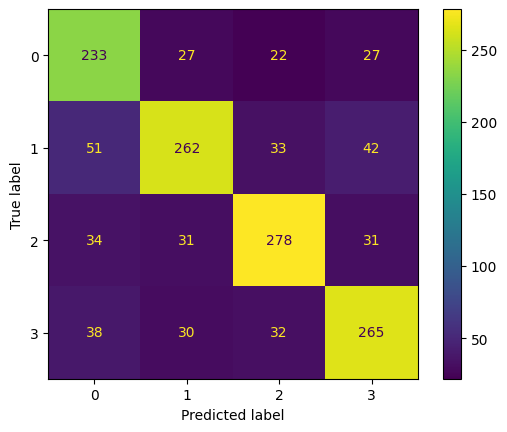

In [ ]:
draw_confusion_matrix(middle_labels, y_pred)

In [ ]:
print_classification_report(middle_labels, y_pred)

              precision    recall  f1-score   support

           0       0.65      0.75      0.70       309
           1       0.75      0.68      0.71       388
           2       0.76      0.74      0.75       374
           3       0.73      0.73      0.73       365

    accuracy                           0.72      1436
   macro avg       0.72      0.72      0.72      1436
weighted avg       0.73      0.72      0.72      1436



**Confusion matrix and performances on high only test data**

In [ ]:
y_high_pred = get_predictions(bert_all_trainer, tokenized_high_data['test'])

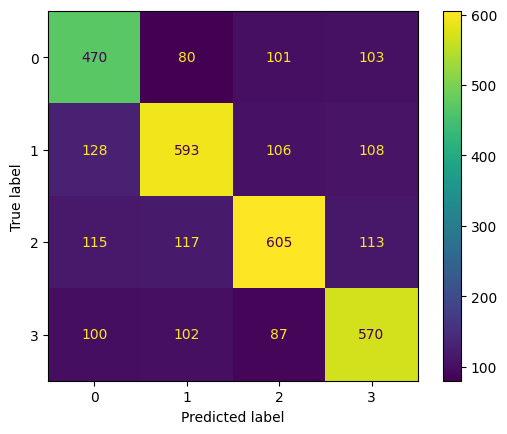

In [ ]:
draw_confusion_matrix(high_labels, y_pred)

In [ ]:
print_classification_report(high_labels, y_pred)

              precision    recall  f1-score   support

           0       0.58      0.62      0.60       754
           1       0.66      0.63      0.65       935
           2       0.67      0.64      0.65       950
           3       0.64      0.66      0.65       859

    accuracy                           0.64      3498
   macro avg       0.64      0.64      0.64      3498
weighted avg       0.64      0.64      0.64      3498



**What can we learn from these metrics?**

The model shows higher performance on Middle difficulty questions, which is expected.
Middle-level questions generally require:

*    Simple fact lookup

*   Direct word or phrase matching

*  Basic contextual understanding with minimal reasoning

In contrast, High-level questions often require:

*    Logical inference beyond the explicit text

*   Abstract or multi-step reasoning

*    The ability to distinguish between semantically similar but incorrect answers

As a result, achieving high performance on High difficulty questions typically requires more advanced models and training procedures, such as:

*    Larger transformer architectures with deeper attention layers

*    Models able to reason

*    Architectures pretrained on more difficult and complex tasks






---



### PERFORMANCES OF BERT TRAINED ONLY ON ONE DIFFICULTY LEVEL

Print metrics computed on middle difficulty test data using the model trained only Middle difficulty data

In [ ]:
bert_middle_model = load_bert_model("./bert_middle")

In [ ]:
bert_middle_trainer = Trainer(
    model=bert_middle_model,
    args=bert_training_args,
)

In [ ]:
y_middle_pred = get_predictions(bert_middle_trainer, tokenized_middle_data['test'])

In [ ]:
print_classification_report(middle_labels, y_pred)

              precision    recall  f1-score   support

           0       0.60      0.69      0.64       309
           1       0.67      0.60      0.64       388
           2       0.68      0.67      0.68       374
           3       0.69      0.68      0.69       365

    accuracy                           0.66      1436
   macro avg       0.66      0.66      0.66      1436
weighted avg       0.66      0.66      0.66      1436



Print metrics computed on both middle and high difficulty test data using the models trained only High difficulty data

In [ ]:
bert_high_model = load_bert_model("./bert_high")

In [ ]:
bert_high_trainer = Trainer(
    model=bert_high_model,
    args=bert_training_args,
)

In [ ]:
y_middle_pred = get_predictions(bert_high_trainer, tokenized_high_data['test'])
y_high_pred = get_predictions(bert_high_trainer, tokenized_high_data['test'])

Metrics on middle difficulty

In [ ]:
print_classification_report(middle_labels, y_middle_pred)

              precision    recall  f1-score   support

           0       0.56      0.66      0.61       309
           1       0.65      0.61      0.62       388
           2       0.69      0.65      0.67       374
           3       0.66      0.65      0.66       365

    accuracy                           0.64      1436
   macro avg       0.64      0.64      0.64      1436
weighted avg       0.64      0.64      0.64      1436



Metrics on high difficulty

In [ ]:
print_classification_report(high_labels, y_high_pred)

              precision    recall  f1-score   support

           0       0.53      0.57      0.55       754
           1       0.61      0.58      0.59       935
           2       0.62      0.60      0.61       950
           3       0.61      0.63      0.62       859

    accuracy                           0.60      3498
   macro avg       0.59      0.60      0.59      3498
weighted avg       0.60      0.60      0.60      3498



**Why the model trained on all data outperforms models trained only on middle or high difficulty data?**

The model trained on the complete dataset, containing both Middle and High difficulty data, achieves better performances even when evaluated separately on Middle or High difficulty questions.
This, in our opinion, can be due to these factors:

*    **Data quantity**: Training on the full dataset exposes the model to a larger number of examples, allowing it to learn more robust and stable patterns

*    **Data diversity**: By encountering both simpler and more complex data during training, the model learns a broader set of linguistic structures and reasoning styles, improving its generalization ability

*    **Better internal representations**: Exposure to a wider range of difficulty levels helps the model build richer, more flexible internal representation, allowing it to adapt more effectively to different types of questions during inference

In contrast, models trained only on Middle or High difficulty data are limited to fewer types of reasoning and linguistic styles.
This restriction leads to less robust feature extraction and weaker generalization, even when evaluated on the specific difficulty they were trained on.

## ANALYSIS OF PREDICTIONS

In this section we are going to examine the predictions, mostly the wrong ones, trying to understand better the reason of the errors

In [ ]:
bert_all_model = load_bert_model("./bert_all")

In [ ]:
bert_all_trainer = Trainer(
    model=bert_all_model,
    args=bert_training_args,
)

In [ ]:
# Predicts options scores and predicted labels for each question
logits = bert_all_trainer.predict(tokenized_data['test'])
y_pred = torch.argmax(torch.tensor(logits.predictions), dim=1).numpy()



---



**Answers distribution**

In this first part we are going to analyze the distribution of the answers computed by the BERT model to check that it generalizes and has not learned to pick always a specific answer

We check 3 distributions:


*   distribution of the labels of the training data
*   distribution of the ground truth labels of the test data
*   distribution of the predicted labels



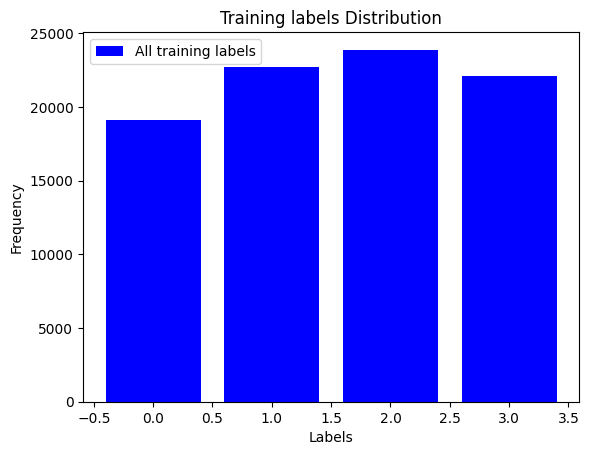

In [ ]:
all_training_labels = get_labels(data['train'])
counts = Counter(all_training_labels)
labels, frequencies = zip(*counts.items())

plt.bar(labels, frequencies, color='blue', label='All training labels')
plt.xlabel("Labels")
plt.ylabel("Frequency")
plt.title("Training labels Distribution")
plt.legend()
plt.show()

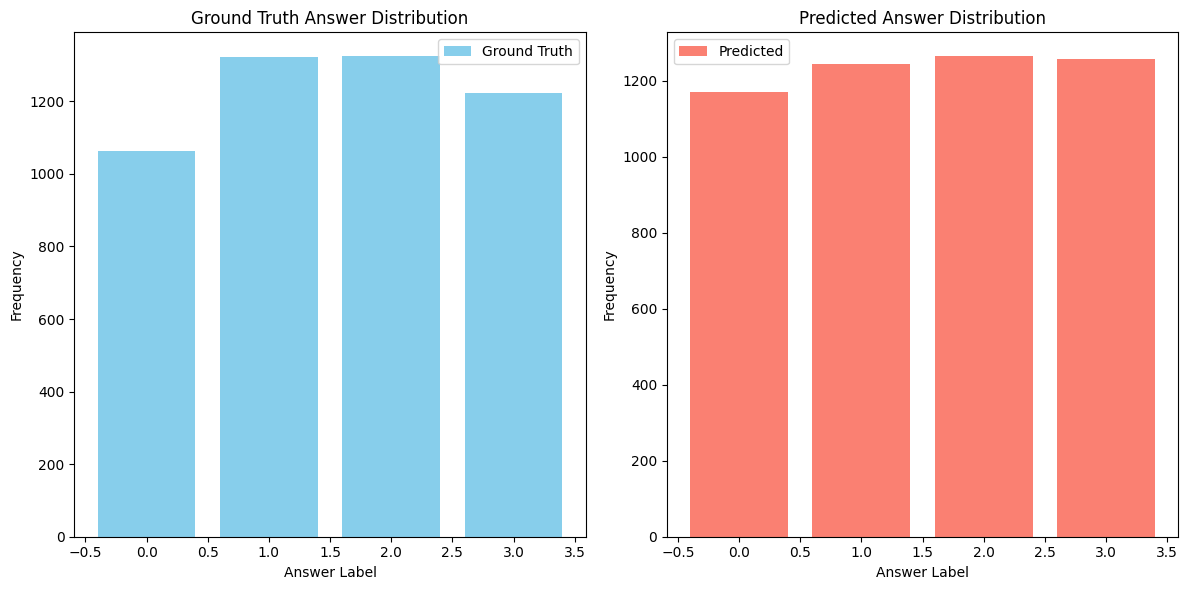

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

def analyze_predictions(y_true, y_pred):


    # Analyze ground truth distribution
    true_counts = Counter(y_true)
    true_labels, true_frequencies = zip(*true_counts.items())

    # Analyze predicted distribution
    predicted_counts = Counter(y_pred)
    predicted_labels, predicted_frequencies = zip(*predicted_counts.items())

    # Plotting
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.bar(true_labels, true_frequencies, color='skyblue', label='Ground Truth')
    plt.xlabel("Answer Label")
    plt.ylabel("Frequency")
    plt.title("Ground Truth Answer Distribution")
    plt.legend()


    plt.subplot(1, 2, 2)
    plt.bar(predicted_labels, predicted_frequencies, color='salmon', label='Predicted')
    plt.xlabel("Answer Label")
    plt.ylabel("Frequency")
    plt.title("Predicted Answer Distribution")
    plt.legend()

    plt.tight_layout()
    plt.show()

analyze_predictions(all_labels, y_pred)


From the distribution analysis we can see that the model tends to predict sligthly less the answer "A", this can be due to:

* The dataset has fewer correct answers labeled "A"
* BERT may be slightly less confident choosing the first option when in doubt

Anyway the distribution is almos uniform, that means:

*   The training and loss functions allowed the model to explore all options without collapsing into a dominant class
*  The model shows a relatively balanced prediction across all answer options.
*  No strong bias was learned toward any particular letter (A/B/C/D).
*  A slight drop in predicting "A" was observed, but not significant enough to suggest a systematic error.

This supports that BERT is attending to the content of the options rather than favoring a fixed position.




---



**Wrong answers analysis**

Now we will analyze the wrong predicted answers looking to:



*   Total number of wrong answers
*   How many of this wrong answers are from high difficulty and how many from middle
*   The average length of the article both in wrong and right cases
*   The wrong answers that are over confident (confidence >0.8 computed using softmax), we analyze the distribution to see how many are from middle difficulty and how many from high, and we look more deeply at the top confident ones



In [ ]:
right_answers = []
wrong_answers = []

for i in range(len(y_pred)):
  if y_pred[i] == all_labels[i]:
    right_answers.append(data['test'][i])
  else:
    wrong_answers.append(data['test'][i])

In [ ]:
print(f"Number of total answers: {len(y_pred)}")
print(f"Number of right answers: {len(right_answers)}")
print(f"Number of wrong answers: {len(wrong_answers)}")
print(f"Number of right answers from middle difficulty: {sum([1 for entry in right_answers if entry['difficulty'] == 'middle'])}")
print(f"Number of right answers from high difficulty: {sum([1 for entry in right_answers if entry['difficulty'] == 'high'])}")
print(f"Number of wrong answers from middle difficulty: {sum([1 for entry in wrong_answers if entry['difficulty'] == 'middle'])}")
print(f"Number of wrong answers from high difficulty: {sum([1 for entry in wrong_answers if entry['difficulty'] == 'high'])}")

Number of total answers: 4934
Number of right answers: 3275
Number of wrong answers: 1659
Number of right answers from middle difficulty: 1038
Number of right answers from high difficulty: 2237
Number of wrong answers from middle difficulty: 398
Number of wrong answers from high difficulty: 1261


Average length of the context of right answers: 1516.142290076336
Average length of the context of wrong answers: 1619.5684147076552



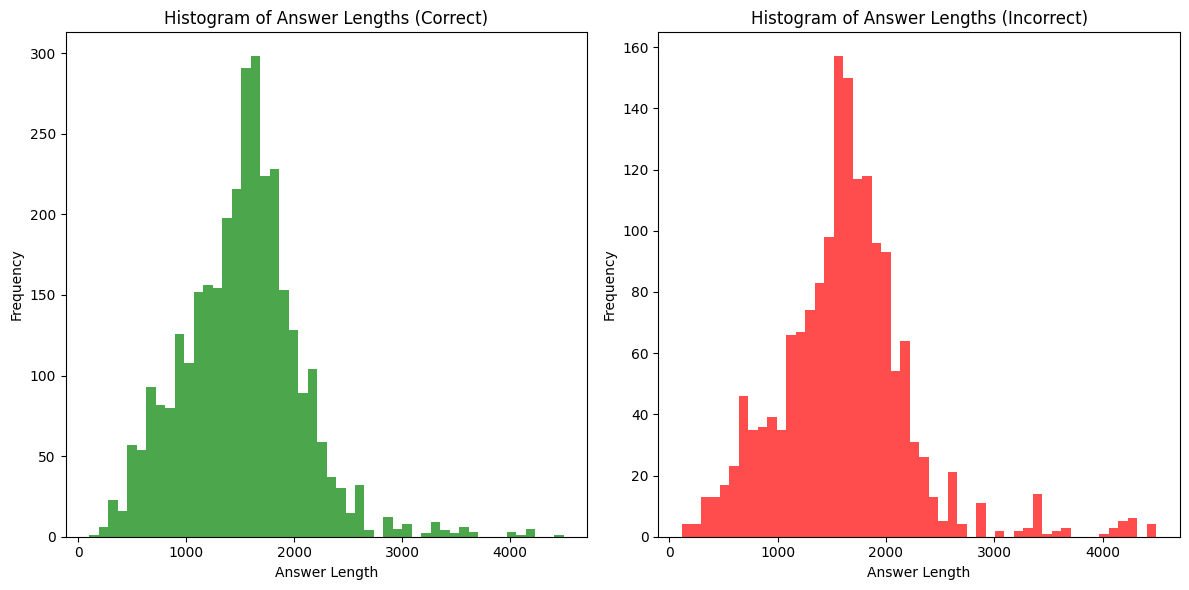

In [ ]:
avg_right_len = sum([len(entry['article_text']) for entry in right_answers]) / len(right_answers)
avg_wrong_len = sum([len(entry['article_text']) for entry in wrong_answers]) / len(wrong_answers)

print(f"Average length of the context of right answers: {avg_right_len}")
print(f"Average length of the context of wrong answers: {avg_wrong_len}\n")

right_lengths = [len(entry['article_text']) for entry in right_answers]
wrong_lengths = [len(entry['article_text']) for entry in wrong_answers]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(right_lengths, bins=50, color='green', alpha=0.7)
plt.title('Histogram of Answer Lengths (Correct)')
plt.xlabel('Answer Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(wrong_lengths, bins=50, color='red', alpha=0.7)
plt.title('Histogram of Answer Lengths (Incorrect)')
plt.xlabel('Answer Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


We can see from the 2 averages and histograms above that even if the average length is slightly higher in the high case the difference is not big enough to be the major reason of this difference in performances.
This proves that the main reason is due principally to the fact that high difficulty questions needs more abstract reasoning as we speculated before



---



In [ ]:
softmax_scores = F.softmax(torch.tensor(logits.predictions), dim=1).numpy()
confidence = softmax_scores[np.arange(len(y_pred)), y_pred]
failure_indices = np.where(y_pred != all_labels)[0]
top_failures = sorted(failure_indices, key=lambda i: -confidence[i])[:100]

High-confidence Failures (>0.8 confidence) from High difficulty: 429
High-confidence Failures (>0.8 confidence) from Middle difficulty: 132



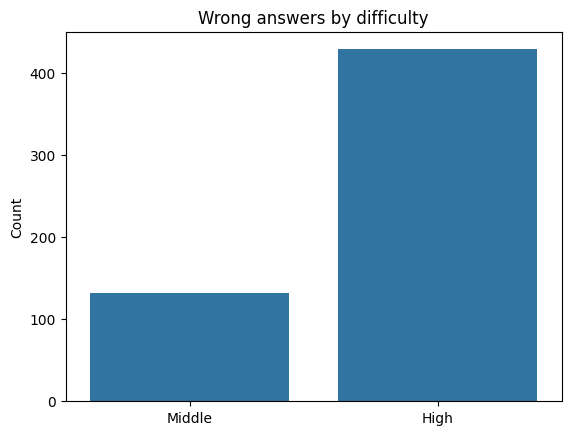

In [ ]:
total_middle = 0
total_high = 0
for i in range(len(y_pred)):
  if (y_pred[i] != all_labels[i]) and (confidence[i] > 0.8):
    total_high += 1 if data['test'][i]['difficulty'] == 'high' else 0
    total_middle += 1 if data['test'][i]['difficulty'] == 'middle' else 0

print(f"High-confidence Failures (>0.8 confidence) from High difficulty: {total_high}")
print(f"High-confidence Failures (>0.8 confidence) from Middle difficulty: {total_middle}\n")

sns.barplot(x=['Middle', 'High'], y=[total_middle, total_high])
plt.title("Wrong answers by difficulty")
plt.ylabel("Count")
plt.show()

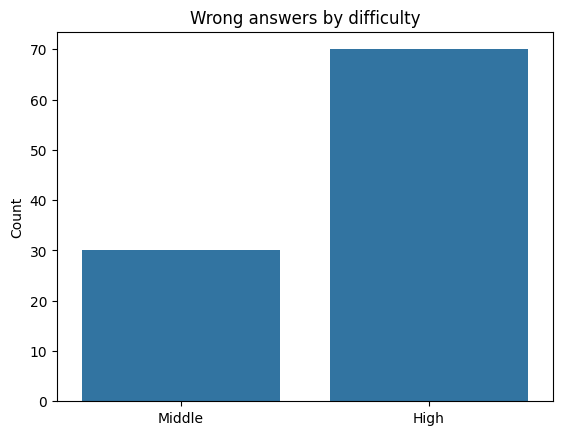

In [ ]:
sns.barplot(x=['Middle', 'High'], y=[sum([1 for i in top_failures if data['test'][int(i)]['difficulty'] == 'middle']),
                                      sum([1 for i in top_failures if data['test'][int(i)]['difficulty'] == 'high'])])
plt.title("Wrong answers by difficulty")
plt.ylabel("Count")
plt.show()

Looking at the graphs above we can see that most of the over confident answers are from the high difficulty texts, this is probably due to the fact that the questions in these cases are more subtle and need a lot of abstraction capabilities, and also can be all valuable answer as can we see below from text number 1.

In [ ]:
for i, idx in enumerate(top_failures[:10]):

  print(f"------TEXT({i+1})------\n")
  print(f"Confidence: {confidence[int(idx)]}\n")
  print(f"Context: {data['test'][int(idx)]['article_text']}\n")
  print(f"Difficulty: {data['test'][int(idx)]['difficulty']}\n")
  print(f"Question: {data['test'][int(idx)]['question']}")
  print(f"Options: {data['test'][int(idx)]['options']}\n")
  print(f"Actual: {all_labels[int(idx)]}")
  print(f"Predicted: {y_pred[int(idx)]}\n")

------TEXT(1)------

Confidence: 0.9999969005584717

Context: A new study has been carried to test the role of story telling in lowering blood pressure. Dr. Thomas Houston, a professor of the University of Massachusetts Medical School, led a group of scientists that investigated how pre-recorded videos of hypertension   patients' talking about their medical histories helped another group of patients with high blood pressure to control their condition over several months.
   Houston was surprised by their studies that suggested that communication can be a powerful tool in medicine. They showed that those who had had similar experiences, when talking to someone with a similar background, could help change their behavior to become healthier. Hypertension is difficult to control, since it is dependent on diet, exercise and mental state. Medical treatments with drugs, and lifestyle therapies  have been  ly ineffective because people find it hard to follow those medical requirements.
   In t

Looking to the top 10 over confident wrong answer using a more human readable fashion we can see that high difficulty texts and questions needs a lot more analysis, inference and abstraction capabiltity.

For example text number 1 asks to find a possible title for the article, the model answer is *Storytelling may help lower blood pressure.* while te right answer is *Medical treatments of blood pressure.*, the two options are strictly semantically correlated and also story telling is mentioned inside the text, so the prediction is not that absurd.



---



## DEBERTA TRAINING

After analyzing the performance of *bert-base-uncased* on the RACE dataset, we observed that the model faced clear limitations, particularly on High difficulty questions that require deeper inference, reasoning and distinguishing between semantically similar answers.

Given that we decided to explore a more advanced architecture specifically designed to address some of BERT’s known weaknesses: DeBERTa (Decoding-enhanced BERT with disentangled attention), more specifically *microsoft/deberta-v3-base*.

DeBERTa introduces several key improvements over the original BERT architecture:

*    **Disentangled Attention**:
    In BERT, the word content and positional information are summed together early in the embedding layer, DeBERTa instead separates content and position into two distinct vectors, allowing the model to compute attention scores by considering the meaning of the words and their relative positions separately.
    This leads to a more deeper understanding of relationships between words, which is critical for handling complex reasoning questions

    **FORMULA**:
$$
\text{score}(i, j) = Q_i^c \cdot K_j^c + Q_i^c \cdot K_{(i-j)}^p
$$

    where:
    * $ Q_i^c $ = Content query for token $i$
    * $ K_j^c $ = Content key for token $j$
    * $ K_{(i-j)}^p $ = Position key depending on the relative position between $i$ and $j$

*    **Relative Positional Encoding**:
    While BERT uses absolute positional embeddings (based on the position of a word in the sentence, each token is assigned a fixed position in the sequence: position 0, position 1, position 2, etc.), DeBERTa uses relative position information (the model learns how far apart two words are, not their absolute positions. This allows the model to focus on the distance and contextual relationships between words improving generalization across varying sentence structures and question styles

*    **Enhanced Pretraining Objectives**:
    DeBERTa is pretrained not only with masked language modeling (MLM, predict the missing token given the context) but also with replaced token detection (the model is trained to detect whether each token in the input has been replaced with a fake token or left unchanged), making its representations stronger and more robust than those produced by BERT.

Thanks to these architectural innovations, DeBERTa models are able to build richer and more flexible internal representations.
This makes them particularly suited for tasks like RACE, where complex inference, abstract reasoning, and subtle semantic understanding are essential for answering High difficulty questions correctly.

Thus, based on the limitations observed with BERT and the theoretical advantages offered by DeBERTa, we selected deberta-base-v3 as the next model to train and evaluate.

**Deberta training**

In [ ]:
# Load model and transfer it into the device
deberta_model = DebertaV2ForMultipleChoice.from_pretrained("microsoft/deberta-v3-base")
deberta_model.to(device)

Some weights of DebertaV2ForMultipleChoice were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DebertaV2ForMultipleChoice(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((76

In [ ]:
print_trainable_parameters(deberta_model)

Trainable parameters: 184422913


In [ ]:
# Define the training arguments for the deberta model
deberta_training_arguments = TrainingArguments(
    "DebertaV3Trainer",
    eval_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,                 # 10% warmup
    fp16=True,
    lr_scheduler_type="cosine",       # Often better than linear
    max_grad_norm=1.0,
    report_to="none",  # Disabling wandb callbacks
)

In [ ]:
# Creation of the trainer
deberta_trainer = Trainer(
    model=deberta_model,
    args=deberta_training_arguments,
    train_dataset=tokenized_data['train'],
    eval_dataset=tokenized_data['validation'],
)

In [ ]:
deberta_trainer.train()

Step,Training Loss
500,1.387900
1000,1.353900
1500,1.161100
2000,1.020100
2500,0.924600
3000,0.881600
3500,0.831900
4000,0.783500
4500,0.787500
5000,0.730200


Step,Training Loss
500,1.387900
1000,1.353900
1500,1.161100
2000,1.020100
2500,0.924600
3000,0.881600
3500,0.831900
4000,0.783500
4500,0.787500
5000,0.730200


TrainOutput(global_step=32952, training_loss=0.5031153900468774, metrics={'train_runtime': 11893.9367, 'train_samples_per_second': 22.162, 'train_steps_per_second': 2.77, 'total_flos': 2.7742467626687693e+17, 'train_loss': 0.5031153900468774, 'epoch': 3.0})

In [ ]:
deberta_trainer.evaluate()

{'eval_loss': 0.9594241976737976,
 'eval_runtime': 86.0034,
 'eval_samples_per_second': 56.823,
 'eval_steps_per_second': 7.104,
 'epoch': 3.0}

In [ ]:
deberta_trainer.save_model("./deberta_all")



---



## DEBERTA EVALUATION

Evaluate the more advanced deBERTa model to see the progress with respect to the previously trained BERT model

In [ ]:
deberta_model = DebertaV2ForMultipleChoice.from_pretrained("./deberta_all")
deberta_model.to(device)

DebertaV2ForMultipleChoice(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((76

In [ ]:
deberta_trainer = Trainer(
    model=deberta_model,
    args=deberta_training_arguments,
)

**Confusion matrix and classification metrics on all test data**

In [ ]:
y_pred = get_predictions(deberta_trainer, tokenized_data['test'])

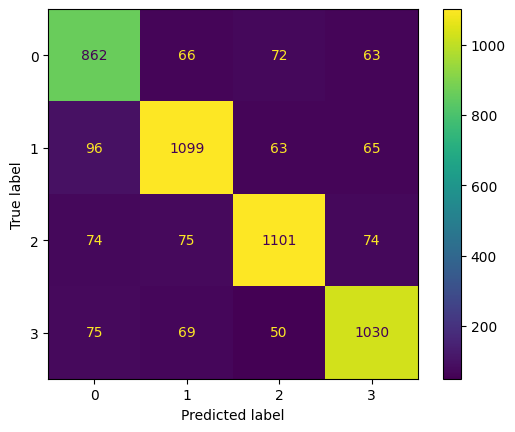

In [ ]:
draw_confusion_matrix(all_labels, y_pred)

In [ ]:
print_classification_report(all_labels, y_pred)

              precision    recall  f1-score   support

           0       0.78      0.81      0.79      1063
           1       0.84      0.83      0.84      1323
           2       0.86      0.83      0.84      1324
           3       0.84      0.84      0.84      1224

    accuracy                           0.83      4934
   macro avg       0.83      0.83      0.83      4934
weighted avg       0.83      0.83      0.83      4934



**Confusion matrix and classification metrics on middle difficulty test data**

In [ ]:
y_middle_pred = get_predictions(deberta_trainer, tokenized_middle_data['test'])

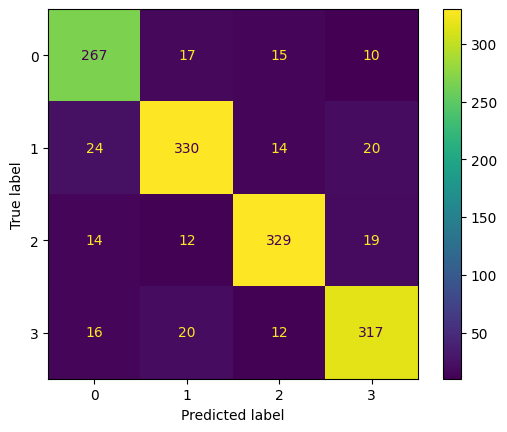

In [ ]:
draw_confusion_matrix(middle_labels, y_middle_pred)

In [ ]:
print_classification_report(middle_labels, y_middle_pred)

              precision    recall  f1-score   support

           0       0.83      0.86      0.85       309
           1       0.87      0.85      0.86       388
           2       0.89      0.88      0.88       374
           3       0.87      0.87      0.87       365

    accuracy                           0.87      1436
   macro avg       0.86      0.87      0.86      1436
weighted avg       0.87      0.87      0.87      1436



**Confusion matrix and classification metrics on high difficulty test data**

In [ ]:
y_high_pred = get_predictions(deberta_trainer, tokenized_high_data['test'])

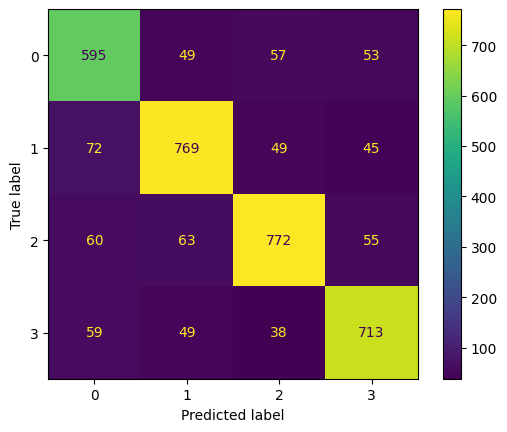

In [ ]:
draw_confusion_matrix(high_labels, y_high_pred)

In [ ]:
print_classification_report(high_labels, y_high_pred)

              precision    recall  f1-score   support

           0       0.76      0.79      0.77       754
           1       0.83      0.82      0.82       935
           2       0.84      0.81      0.83       950
           3       0.82      0.83      0.83       859

    accuracy                           0.81      3498
   macro avg       0.81      0.81      0.81      3498
weighted avg       0.82      0.81      0.81      3498



After training DeBERTa Base v3 on the full RACE dataset (containing both Middle and High difficulty examples), we evaluated its performance separately on different subsets of the test set. The results are summarized as follows:

| Test Set            | Accuracy |
|:--------------------|:--------:|
| Full difficulty   | 83%      |
| Middle difficulty     | 87%      |
| High test set       | 81%      |


This shows what we expected, using a more complex model with newer  architectural improvements leads to a significant increase in performance across all difficulty levels.

As a result, the model handles both simple fact-based questions (Middle difficulty) and more challenging reasoning questions (High difficulty) more effectively than earlier models like BERT.

The higher accuracy on Middle difficulty (87%) indicates that the model easily masters basic reasoning tasks, while the strong performance on High difficulty (81%) confirms its ability to generalize to more abstract and multi-step inference questions.

The results validate that upgrading the model architecture can directly translate into improved comprehension and reasoning abilities on complex multiple-choice reading comprehension datasets like RACE.



---



**Analysis of wrong answers difficulty with deBERTa model**

In [ ]:
logits = deberta_trainer.predict(tokenized_data['test'])
y_pred = torch.argmax(torch.tensor(logits.predictions), dim=1).numpy()

In [ ]:
right_answers = []
wrong_answers = []

for i in range(len(y_pred)):
  if y_pred[i] == all_labels[i]:
    right_answers.append(data['test'][i])
  else:
    wrong_answers.append(data['test'][i])

In [ ]:
print(f"Number of total answers: {len(y_pred)}")
print(f"Number of right answers: {len(right_answers)}")
print(f"Number of wrong answers: {len(wrong_answers)}")
print(f"Number of right answers from middle difficulty: {sum([1 for entry in right_answers if entry['difficulty'] == 'middle'])}")
print(f"Number of right answers from high difficulty: {sum([1 for entry in right_answers if entry['difficulty'] == 'high'])}")
print(f"Number of wrong answers from middle difficulty: {sum([1 for entry in wrong_answers if entry['difficulty'] == 'middle'])}")
print(f"Number of wrong answers from high difficulty: {sum([1 for entry in wrong_answers if entry['difficulty'] == 'high'])}")

Number of total answers: 4934
Number of right answers: 4092
Number of wrong answers: 842
Number of right answers from middle difficulty: 1243
Number of right answers from high difficulty: 2849
Number of wrong answers from middle difficulty: 193
Number of wrong answers from high difficulty: 649


<br>
<br>

| Model     | # Middle Wrong |# High Wrong  |
|:----------|:----------------:|:--------------:|
| BERT Base | (100 - 72)% = 28%           | (100 - 64)% = 36%          |
| DeBERTa Base v3 | (100 - 87)% = 13% | (100 - 81)% = 19% |


<br>
<br>


| Model     | Middle Wrong (%) | High Wrong (%) |
|:----------|:----------------:|:--------------:|
| BERT Base |     398        |       1261    |
| DeBERTa Base v3 | 193 | 649|

<br>
<br>

From the percentages in the table we can see that deBERTa has decreased the percentage of Middle difficulty wrong answer by the 15% and the high difficulty ones by 17%.

**Overall the results demonstrate that DeBERTa not only boosts general performance but is particularly effective at handling the more cognitively demanding questions that were a major challenge for earlier models like BERT.**